In [1]:
from wildlife_datasets import analysis, datasets

/scratch4/home/adempst/projects/open_vocab_mot/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
!uv run kaggle auth login

You are already logged-in to Kaggle as [adempster].
Please use the --force flag to override.


In [3]:
from open_vocab_mot import WILDLIFE_10K_PATH, WILDLIFE_10K_SIDECAR_PATH
print(WILDLIFE_10K_PATH, WILDLIFE_10K_SIDECAR_PATH)

/scratch4/home/adempst/projects/open_vocab_mot/dat/Wildlife10K /scratch4/home/adempst/projects/open_vocab_mot/dat/Wildlife10K_sidecar


In [4]:
datasets.WildlifeReID10k.get_data(str(WILDLIFE_10K_PATH))

DATASET WildlifeReID10k: DOWNLOADING STARTED.
You are trying to download an already downloaded dataset.
        This message may have happened to due interrupted download or extract.
        To force the download use the `force=True` keyword such as
        get_data(..., force=True) or download(..., force=True).
        


In [5]:
wildlife_10k = datasets.WildlifeReID10k(str(WILDLIFE_10K_PATH))

In [6]:
wildlife_10k.df

,image_id,identity,path,date,orientation,species,split,dataset,cluster_id
0,0,AAUZebraFish_5,images/AAUZebraFish/data/Vid2_0520_0000ef3f3f3...,NaN,right,fish,train,AAUZebraFish,AAUZebraFish_5_0
1,1,AAUZebraFish_3,images/AAUZebraFish/data/Vid1_0062_0002c4ff6de...,NaN,right,fish,train,AAUZebraFish,NaN
2,2,AAUZebraFish_4,images/AAUZebraFish/data/Vid2_1065_000444965a5...,NaN,right,fish,test,AAUZebraFish,NaN
3,3,AAUZebraFish_6,images/AAUZebraFish/data/Vid2_0381_001446b650f...,NaN,right,fish,train,AAUZebraFish,NaN
4,4,AAUZebraFish_2,images/AAUZebraFish/data/Vid1_0582_00173b45939...,NaN,left,fish,test,AAUZebraFish,NaN
...,...,...,...,...,...,...,...,...,...
140483,140483,ZindiTurtleRecall_t_id_ip3jsrYo,images/ZindiTurtleRecall/images/ID_ZYTRP3VN_ID...,NaN,left,sea turtle,train,ZindiTurtleRecall,NaN
140484,140484,ZindiTurtleRecall_t_id_o8HFaaCp,images/ZindiTurtleRecall/images/ID_ZZ04P34G_ID...,NaN,NaN,sea turtle,test,ZindiTurtleRecall,NaN
140485,140485,ZindiTurtleRecall_t_id_ruF8Nbxs,images/ZindiTurtleRecall/images/ID_ZZD2VBPA_ID...,NaN,NaN,sea turtle,train,ZindiTurtleRecall,NaN
140486,140486,ZindiTurtleRecall_t_id_m2JvEcsg,images/ZindiTurtleRecall/images/ID_ZZEGHRM5_ID...,NaN,left,sea turtle,train,ZindiTurtleRecall,NaN


In [7]:
wildlife_10k.df["dataset"].unique()


<ArrowStringArray>
[           'AAUZebraFish',        'AerialCattle2017',
       'AmvrakikosTurtles',                    'ATRW',
                'BelugaID',        'BirdIndividualID',
     'CatIndividualImages',           'Chicks4FreeID',
              'CowDataset',                'Cows2021',
                    'CTai',                    'CZoo',
              'DogFaceNet',      'FriesianCattle2015',
      'FriesianCattle2017',                'Giraffes',
          'GiraffeZebraID',             'HyenaID2022',
                'IPanda50',           'LeopardID2022',
                    'MPDD',        'MultiCamCows2024',
                   'NDD20',               'NyalaData',
            'OpenCows2020',          'PolarBearVidID',
                'PrimFace',          'ReunionTurtles',
                  'SealID',         'SeaStarReID2023',
         'SeaTurtleID2022',                  'SMALST',
 'SouthernProvinceTurtles',           'StripeSpotter',
            'WhaleSharkID',        'Zakynthos

In [ ]:
wildlife_10k.df["split"].unique()

In [ ]:
counts = wildlife_10k.df["identity"].value_counts()
valid_identities = counts[counts >= 8*3].index
restricted_df = wildlife_10k.df[wildlife_10k.df["identity"].isin(valid_identities)].copy()

In [ ]:
# restricted_df

In [ ]:
# restricted_df[restricted_df["identity"] == "ZindiTurtleRecall_t_id_m2JvEcsg"]

In [9]:
from open_vocab_mot.data import Wildlife10KSubsetDataset, Wildlife10KSplit, Wildlife10KDatasets, VideoReIDKPFBatchIterableDataset, VideoReIDItem, collate_video_reid_ds

In [95]:
dataset_id: Wildlife10KDatasets = "CTai"

In [96]:
test_df = wildlife_10k.df[wildlife_10k.df["dataset"] == dataset_id]
# test_df = wildlife_10k.df[wildlife_10k.df["cluster_id"] == "BelugaID_whale000_0"]
test_df

,image_id,identity,path,date,orientation,species,split,dataset,cluster_id
43790,43790,CTai_Fredy,images/CTai/chimpanzee_faces-master/datasets_c...,NaN,NaN,chimpanzee,train,CTai,NaN
43791,43791,CTai_Victor,images/CTai/chimpanzee_faces-master/datasets_c...,NaN,NaN,chimpanzee,train,CTai,NaN
43792,43792,CTai_Fredy,images/CTai/chimpanzee_faces-master/datasets_c...,NaN,NaN,chimpanzee,test,CTai,NaN
43793,43793,CTai_Victor,images/CTai/chimpanzee_faces-master/datasets_c...,NaN,NaN,chimpanzee,test,CTai,NaN
43794,43794,CTai_Fredy,images/CTai/chimpanzee_faces-master/datasets_c...,NaN,NaN,chimpanzee,train,CTai,CTai_Fredy_2
...,...,...,...,...,...,...,...,...,...
48447,48447,CTai_Besar,images/CTai/chimpanzee_faces-master/datasets_c...,NaN,NaN,chimpanzee,train,CTai,NaN
48448,48448,CTai_Mkubwa,images/CTai/chimpanzee_faces-master/datasets_c...,NaN,NaN,chimpanzee,train,CTai,NaN
48449,48449,CTai_Atra,images/CTai/chimpanzee_faces-master/datasets_c...,NaN,NaN,chimpanzee,train,CTai,NaN
48450,48450,CTai_Kuba,images/CTai/chimpanzee_faces-master/datasets_c...,NaN,NaN,chimpanzee,test,CTai,NaN


In [97]:
test_ds = Wildlife10KSubsetDataset(
    WILDLIFE_10K_PATH,
    dataset_id,
    Wildlife10KSplit.TRAIN,
    sidecar_root=WILDLIFE_10K_SIDECAR_PATH,
    load_image_pil=True,
    load_image_tensor=False,
    load_segmentations=True,
    pre_loaded_ds=wildlife_10k,
    verbose=True
)

/scratch4/home/adempst/projects/open_vocab_mot/src/open_vocab_mot/data/wildlife_10k_subset_ds.py:128: UserWarning: you are shuffling a 'ArrowStringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(unique_train_identities)


Preparring WildlifeReID10k subset CTai with 68 train identities and 70 test identities above the image count threshold


Processing WildlifeReID10k subset CTai: 100%|██████████| 2608/2608 [00:00<00:00, 40914.84it/s]


In [98]:
sample = test_ds[10]
sample


VideoReIDItem(
    sample_index=10,
    identity_id=0,
    sequence_id=1,
    frame_id=43816,
    frame_path=PosixPath('/scratch4/home/adempst/projects/open_vocab_mot/dat/Wildlife10K/images/CTai/chimpanzee_faces-master/datasets_cropped_chimpanzee_faces/data_CTai/face_images/img-id21-object-1_26.png'),
    frame=<PIL.Image.Image image mode=RGB size=236x163 at 0x780981834830>,
    frame_tensor=None,
    segmentation_path=PosixPath('/scratch4/home/adempst/projects/open_vocab_mot/dat/Wildlife10K_sidecar/images/CTai/chimpanzee_faces-master/datasets_cropped_chimpanzee_faces/data_CTai/face_images/img-id21-object-1_26.png'),
    segmentation_tensor=tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])
)

In [99]:
from IPython.display import display
from torchvision.transforms.v2.functional import to_pil_image

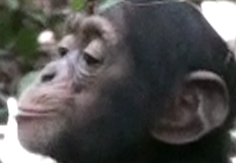

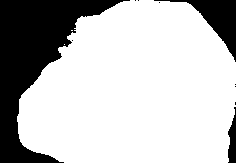

In [100]:
display(sample.frame)
display(to_pil_image(sample.segmentation_tensor))

In [101]:
from torch.utils.data import DataLoader
sampler_ds = VideoReIDKPFBatchIterableDataset(
    test_ds, batches_per_epoch=100,
    num_identities_per_batch=1,
    num_sequences_per_identity=2,
    num_frames_per_sequence=2,
    allow_same_identity_same_sequence=True,
    allow_resampling_sample_indices=True
)

sampler_loader = DataLoader(sampler_ds, batch_size=None, collate_fn=collate_video_reid_ds)

In [108]:
batch: VideoReIDItem = next(iter(sampler_loader))

In [109]:
batch


VideoReIDBatch(
    sample_indices=tensor([ 199,  198, 2114, 2113]),
    identity_ids=tensor([4, 4, 4, 4]),
    sequence_ids=tensor([ 18,  18, 100, 100]),
    frame_ids=[44270, 44269, 47686, 47685],
    frame_paths=[
        PosixPath('/scratch4/home/adempst/projects/open_vocab_mot/dat/Wildlife10K/images/CTai/chimpanzee_faces-master/datasets_cropped_chimpanzee_faces/data_CTai/face_images/img-id396-object-1_491.png'),
        PosixPath('/scratch4/home/adempst/projects/open_vocab_mot/dat/Wildlife10K/images/CTai/chimpanzee_faces-master/datasets_cropped_chimpanzee_faces/data_CTai/face_images/img-id395-object-1_490.png'),
        PosixPath('/scratch4/home/adempst/projects/open_vocab_mot/dat/Wildlife10K/images/CTai/chimpanzee_faces-master/datasets_cropped_chimpanzee_faces/data_CTai/face_images/img-id3204-object-1_4215.png'),
        PosixPath('/scratch4/home/adempst/projects/open_vocab_mot/dat/Wildlife10K/images/CTai/chimpanzee_faces-master/datasets_cropped_chimpanzee_faces/data_CTai/face_i

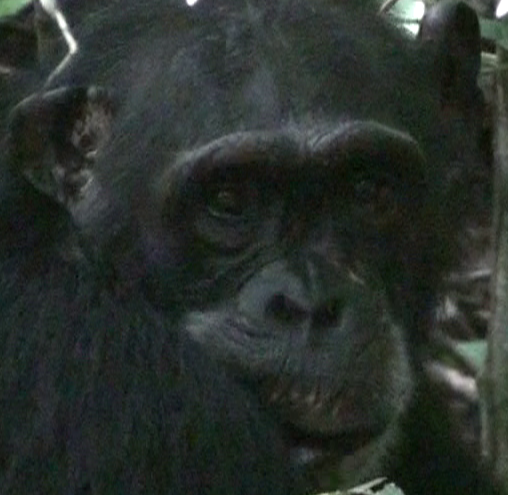

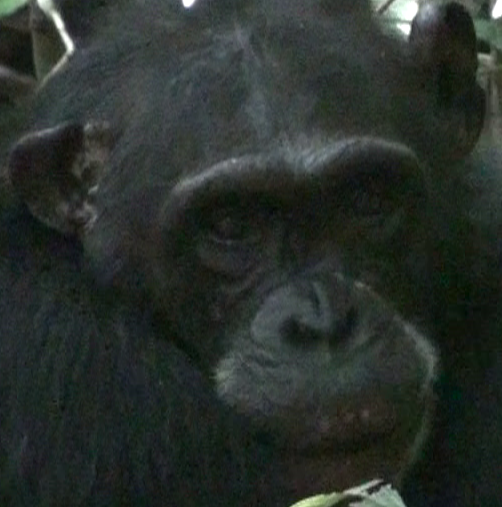

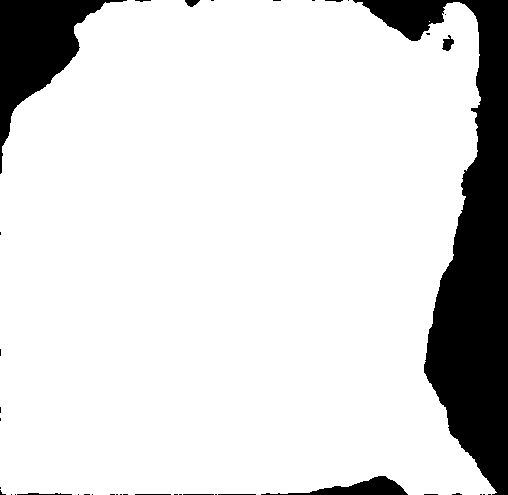

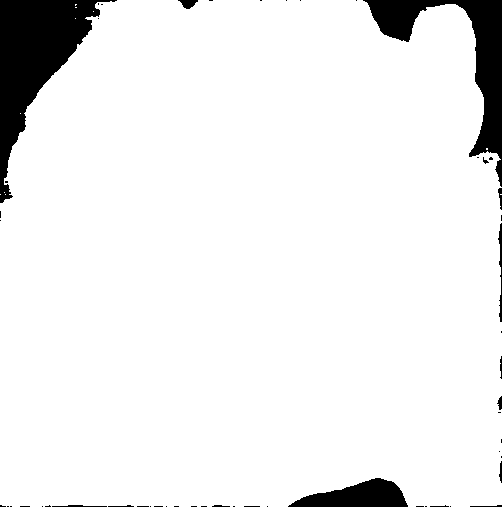

In [110]:
display(batch.frames[0])
display(batch.frames[1])
display(to_pil_image(batch.segmentations[0]))
display(to_pil_image(batch.segmentations[1]))

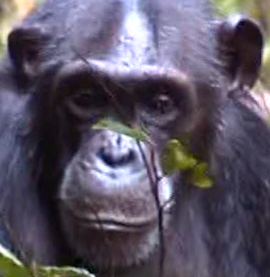

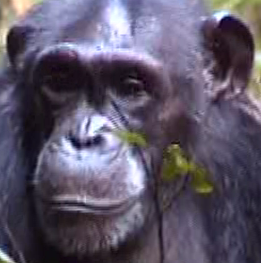

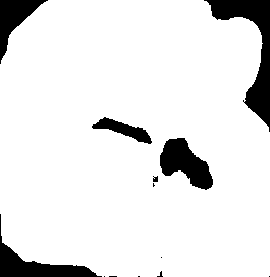

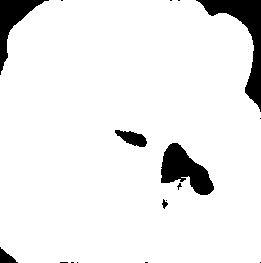

In [111]:
display(batch.frames[2])
display(batch.frames[3])
display(to_pil_image(batch.segmentations[2]))
display(to_pil_image(batch.segmentations[3]))